In [3]:
import sys
!{sys.executable} -m pip install tqdm

  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [1]:
!pip install pydicom opencv-python matplotlib tqdm

In [4]:
import os
import cv2
import numpy as np
import pydicom
from tqdm import tqdm
import matplotlib.pyplot as plt

In [11]:
import zipfile
import os

zip_path = r"C:\Users\shrey\Downloads\z4wc364g79-1.zip"

extract_path = r"C:\Users\shrey\Desktop\dataset"

# Create folder
os.makedirs(extract_path, exist_ok=True)

# Extract ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("ZIP Extracted Successfully")

ZIP Extracted Successfully


In [12]:
import os

print(os.listdir(r"C:\Users\shrey\Desktop\dataset"))

['z4wc364g79-1']


In [13]:
import os

dataset_path = r"C:\Users\shrey\Desktop\dataset"

dcm_count = 0

for root, dirs, files in os.walk(dataset_path):
    
    for file in files:
        
        if file.endswith(".dcm"):
            dcm_count += 1

print("Total DICOM Files:", dcm_count)

Total DICOM Files: 356


In [17]:
import os
import cv2
import numpy as np
import pydicom
from tqdm import tqdm

# Input dataset path
dataset_path = r"C:\Users\shrey\Desktop\dataset"

# Output path
output_folder = r"C:\Users\shrey\Desktop\Patient_Wise_Images"

os.makedirs(output_folder, exist_ok=True)

count = 0

for root, dirs, files in os.walk(dataset_path):

    for file in tqdm(files):

        if file.endswith(".dcm"):

            dicom_path = os.path.join(root, file)

            try:
                # Read DICOM
                dicom = pydicom.dcmread(dicom_path)

                # Extract image
                image = dicom.pixel_array

                # Normalize
                image = image.astype(np.float32)
                image = (np.maximum(image, 0) / image.max()) * 255.0
                image = np.uint8(image)

                # Resize
                image = cv2.resize(image, (224, 224))

                # -----------------------------
                # Patient Folder Name
                # -----------------------------
                
                patient_folder = os.path.basename(root)

                patient_output_folder = os.path.join(
                    output_folder,
                    patient_folder
                )

                os.makedirs(patient_output_folder, exist_ok=True)

                # Image Name
                image_name = os.path.splitext(file)[0] + ".png"

                save_path = os.path.join(
                    patient_output_folder,
                    image_name
                )

                # Save image
                cv2.imwrite(save_path, image)

                count += 1

            except Exception as e:
                print(f"Error in {file}: {e}")

print("\nTotal Images Saved:", count)

0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 1/1 [00:00<?, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 88/88 [00:00<00:00, 230.72it/s]
0it [00:00, ?it/s]
100%|██████████| 90/90 [00:00<00:00, 208.58it/s]


Total Images Saved: 356


In [57]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import json
import pandas as pd
from datetime import datetime
import glob
from scipy import ndimage

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [61]:
# ============ CONFIGURATION ============
IMG_SIZE = (300, 300)

# Update these paths
MODELS_FOLDER = r"C:\Users\shrey\OneDrive\Desktop\mini project\Topics"

# Your actual patient-wise image structure
BASE_DATASET = r"C:\Users\shrey\OneDrive\Desktop\mini project\Topics\Patient_Wise_Images"
# Separate folders for images and masks
IMAGE_CT_FOLDER = os.path.join(BASE_DATASET, "image_CT")
IMAGE_MR_FOLDER = os.path.join(BASE_DATASET, "image_MR")
MASK_CT_FOLDER = os.path.join(BASE_DATASET, "mask_CT")
MASK_MR_FOLDER = os.path.join(BASE_DATASET, "mask_MR")

# Create output directories
os.makedirs("fusion_patient_gradcam_analysis", exist_ok=True)

print("✅ Configuration loaded")
print(f"   MODELS_FOLDER: {MODELS_FOLDER}")
print(f"   IMAGE_CT_FOLDER: {IMAGE_CT_FOLDER}")
print(f"   IMAGE_MR_FOLDER: {IMAGE_MR_FOLDER}")
print(f"   MASK_CT_FOLDER: {MASK_CT_FOLDER}")
print(f"   MASK_MR_FOLDER: {MASK_MR_FOLDER}")

# Verify folders exist
for folder, name in [(IMAGE_CT_FOLDER, "CT Images"), 
                      (IMAGE_MR_FOLDER, "MR Images"),
                      (MASK_CT_FOLDER, "CT Masks"), 
                      (MASK_MR_FOLDER, "MR Masks")]:
    if os.path.exists(folder):
        files = [f for f in os.listdir(folder) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        print(f"   ✅ {name} folder found ({len(files)} files)")
    else:
        print(f"   ❌ {name} folder NOT found")

✅ Configuration loaded
   MODELS_FOLDER: C:\Users\shrey\OneDrive\Desktop\mini project\Topics
   IMAGE_CT_FOLDER: C:\Users\shrey\OneDrive\Desktop\mini project\Topics\Patient_Wise_Images\image_CT
   IMAGE_MR_FOLDER: C:\Users\shrey\OneDrive\Desktop\mini project\Topics\Patient_Wise_Images\image_MR
   MASK_CT_FOLDER: C:\Users\shrey\OneDrive\Desktop\mini project\Topics\Patient_Wise_Images\mask_CT
   MASK_MR_FOLDER: C:\Users\shrey\OneDrive\Desktop\mini project\Topics\Patient_Wise_Images\mask_MR
   ✅ CT Images folder found (88 files)
   ✅ MR Images folder found (90 files)
   ✅ CT Masks folder found (88 files)
   ✅ MR Masks folder found (90 files)


In [62]:
def load_patient_images(image_ct_folder, image_mr_folder, mask_ct_folder, mask_mr_folder, 
                       num_patients=5, use_mri="T1"):
    """
    Load patient images AND masks from organized folders
    
    Structure:
    Patient_Wise_Images/
    ├── image_CT/
    │   ├── image1.png
    │   └── ...
    ├── image_MR/
    │   ├── image1.png
    │   └── ...
    ├── mask_CT/
    │   ├── image1_mask.png
    │   └── ...
    └── mask_MR/
        ├── image1_mask.png
        └── ...
    """
    patient_data = []
    
    # Get all image files
    ct_images = sorted(glob.glob(os.path.join(image_ct_folder, "*.png")))
    mr_images = sorted(glob.glob(os.path.join(image_mr_folder, "*.png")))
    
    ct_masks = sorted(glob.glob(os.path.join(mask_ct_folder, "*.png")))
    mr_masks = sorted(glob.glob(os.path.join(mask_mr_folder, "*.png")))
    
    print(f"Found:")
    print(f"  CT images: {len(ct_images)}")
    print(f"  MR images: {len(mr_images)}")
    print(f"  CT masks: {len(ct_masks)}")
    print(f"  MR masks: {len(mr_masks)}")
    
    # Match images with masks (by filename)
    for idx in range(min(num_patients, len(ct_images), len(mr_images))):
        ct_image = ct_images[idx]
        mr_image = mr_images[idx]
        
        # Try to find corresponding masks
        ct_mask = None
        mr_mask = None
        
        # Extract base filename
        ct_basename = os.path.splitext(os.path.basename(ct_image))[0]
        mr_basename = os.path.splitext(os.path.basename(mr_image))[0]
        
        # Find matching masks
        for mask in ct_masks:
            if ct_basename in os.path.basename(mask):
                ct_mask = mask
                break
        
        for mask in mr_masks:
            if mr_basename in os.path.basename(mask):
                mr_mask = mask
                break
        
        # If exact match not found, use corresponding index
        if ct_mask is None and idx < len(ct_masks):
            ct_mask = ct_masks[idx]
        
        if mr_mask is None and idx < len(mr_masks):
            mr_mask = mr_masks[idx]
        
        patient_data.append({
            'patient_id': f"Patient_{idx+1:02d}",
            'patient_idx': idx + 1,
            'ct_image': ct_image,
            'mri_image': mr_image,
            'ct_mask': ct_mask,
            'mri_mask': mr_mask,
            'mri_type': use_mri
        })
    
    return patient_data

# Load patients
print("\n" + "="*80)
print("LOADING PATIENT-WISE IMAGES WITH MASKS")
print("="*80)

patient_data = load_patient_images(IMAGE_CT_FOLDER, IMAGE_MR_FOLDER, 
                                    MASK_CT_FOLDER, MASK_MR_FOLDER,
                                    num_patients=5, use_mri="T1")

if len(patient_data) == 0:
    print("\n❌ ERROR: No patients loaded!")
else:
    print(f"\n✅ Successfully loaded {len(patient_data)} patients")
    for p in patient_data:
        print(f"\n   Patient {p['patient_idx']}: {p['patient_id']}")
        print(f"      CT Image: {os.path.basename(p['ct_image'])}")
        print(f"      MR Image: {os.path.basename(p['mri_image'])}")
        ct_mask_status = '✅' if p['ct_mask'] and os.path.exists(p['ct_mask']) else '❌'
        mr_mask_status = '✅' if p['mri_mask'] and os.path.exists(p['mri_mask']) else '❌'
        print(f"      CT Mask: {ct_mask_status} {os.path.basename(p['ct_mask']) if p['ct_mask'] else 'Not found'}")
        print(f"      MR Mask: {mr_mask_status} {os.path.basename(p['mri_mask']) if p['mri_mask'] else 'Not found'}")


LOADING PATIENT-WISE IMAGES WITH MASKS
Found:
  CT images: 88
  MR images: 90
  CT masks: 88
  MR masks: 90

✅ Successfully loaded 5 patients

   Patient 1: Patient_01
      CT Image: 10_CT_s1.png
      MR Image: 10_MR_s1.png
      CT Mask: ✅ 10_CT_m1.png
      MR Mask: ✅ 10_MR_m1.png

   Patient 2: Patient_02
      CT Image: 10_CT_s2.png
      MR Image: 10_MR_s2.png
      CT Mask: ✅ 10_CT_m2.png
      MR Mask: ✅ 10_MR_m2.png

   Patient 3: Patient_03
      CT Image: 10_CT_s3.png
      MR Image: 10_MR_s3.png
      CT Mask: ✅ 10_CT_m3.png
      MR Mask: ✅ 10_MR_m3.png

   Patient 4: Patient_04
      CT Image: 10_CT_s4.png
      MR Image: 10_MR_s4.png
      CT Mask: ✅ 10_CT_m4.png
      MR Mask: ✅ 10_MR_m4.png

   Patient 5: Patient_05
      CT Image: 10_CT_s5.png
      MR Image: 10_MR_s5.png
      CT Mask: ✅ 10_CT_m5.png
      MR Mask: ✅ 10_MR_m5.png


In [63]:
print("Loading pre-trained models...")

try:
    # Load models from your Topics folder
    ct_model_full = tf.keras.models.load_model(os.path.join(MODELS_FOLDER, "ct_model.h5"))
    mri_model_full = tf.keras.models.load_model(os.path.join(MODELS_FOLDER, "mri_model.h5"))
    fusion_model = tf.keras.models.load_model(os.path.join(MODELS_FOLDER, "fusion_model.h5"))
    
    print("✅ Models loaded successfully")
    
    # Show model info
    print(f"\nModel Information:")
    print(f"  CT Model parameters: {ct_model_full.count_params():,}")
    print(f"  MRI Model parameters: {mri_model_full.count_params():,}")
    print(f"  Fusion Model parameters: {fusion_model.count_params():,}")
    
    print("\n✅ Ready for feature extraction")
    
except FileNotFoundError as e:
    print(f"❌ Error: Could not find model files in {MODELS_FOLDER}")
    print(f"   Please verify the paths are correct")
    raise
except Exception as e:
    print(f"❌ Error loading models: {e}")
    raise

Loading pre-trained models...


✅ Models loaded successfully

Model Information:
  CT Model parameters: 18,599,520
  MRI Model parameters: 18,599,520
  Fusion Model parameters: 691,201

✅ Ready for feature extraction


In [64]:
print("Creating feature extractors from trained models...")

try:
    # Get the Dense(512) layer output (before dropout)
    ct_feature_output = ct_model_full.layers[-3].output
    mri_feature_output = mri_model_full.layers[-3].output
    
    print(f"\n✅ Using Dense layers as feature extractors:")
    print(f"   CT: layer[-3] = {ct_model_full.layers[-3].name}")
    print(f"   MRI: layer[-3] = {mri_model_full.layers[-3].name}")
    
    # Create extractors
    ct_extractor = tf.keras.Model(
        inputs=ct_model_full.input,
        outputs=ct_feature_output
    )
    
    mri_extractor = tf.keras.Model(
        inputs=mri_model_full.input,
        outputs=mri_feature_output
    )
    
    print(f"\n✅ Feature extractors created")
    
    # Get dimensions
    ct_output_shape = ct_extractor.output_shape
    mri_output_shape = mri_extractor.output_shape
    
    print(f"   CT extractor output shape: {ct_output_shape}")
    print(f"   MRI extractor output shape: {mri_output_shape}")
    
except Exception as e:
    print(f"❌ Error with layer -3: {e}")
    print(f"   Trying layer -2 instead...")
    
    try:
        ct_feature_output = ct_model_full.layers[-2].output
        mri_feature_output = mri_model_full.layers[-2].output
        
        ct_extractor = tf.keras.Model(
            inputs=ct_model_full.input,
            outputs=ct_feature_output
        )
        
        mri_extractor = tf.keras.Model(
            inputs=mri_model_full.input,
            outputs=mri_feature_output
        )
        
        ct_output_shape = ct_extractor.output_shape
        mri_output_shape = mri_extractor.output_shape
        
        print(f"   ✅ Using layer -2 instead")
        print(f"   CT output shape: {ct_output_shape}")
        print(f"   MRI output shape: {mri_output_shape}")
        
    except Exception as e2:
        print(f"❌ Failed again: {e2}")
        raise

# Verify dimensions
print(f"\n📊 DIMENSION CHECK:")

ct_dim = ct_output_shape[-1]
mri_dim = mri_output_shape[-1]
fusion_input_dim = fusion_model.input_shape[-1]
total_dim = ct_dim + mri_dim

print(f"   CT feature dimension: {ct_dim}")
print(f"   MRI feature dimension: {mri_dim}")
print(f"   Combined: {total_dim}")
print(f"   Fusion model expects: {fusion_input_dim}")

if total_dim == fusion_input_dim:
    print(f"\n   ✅ PERFECT! Dimensions match exactly")

print("\n✅ Feature extractors ready!")

Creating feature extractors from trained models...

✅ Using Dense layers as feature extractors:
   CT: layer[-3] = dense
   MRI: layer[-3] = dense_2

✅ Feature extractors created
   CT extractor output shape: (None, 512)
   MRI extractor output shape: (None, 512)

📊 DIMENSION CHECK:
   CT feature dimension: 512
   MRI feature dimension: 512
   Combined: 1024
   Fusion model expects: 1024

   ✅ PERFECT! Dimensions match exactly

✅ Feature extractors ready!


In [65]:
def preprocess_image(image_path):
    """
    Load and preprocess a single image
    Returns: preprocessed image batch and RGB image for visualization
    """
    try:
        # Read image
        img = cv2.imread(image_path)
        if img is None:
            return None, None
        
        # Convert BGR to RGB
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Resize
        img_resized = cv2.resize(img_rgb, IMG_SIZE)
        
        # Normalize to [0, 1]
        img_float = tf.cast(img_resized, tf.float32) / 255.0
        
        # Z-score normalization
        mean = tf.reduce_mean(img_float)
        std = tf.math.reduce_std(img_float) + 1e-6
        img_normalized = (img_float - mean) / std
        
        # Add batch dimension
        img_batch = tf.expand_dims(img_normalized, 0)
        
        return img_batch, img_rgb
        
    except Exception as e:
        print(f"Error preprocessing image: {e}")
        return None, None

print("✅ Preprocessing function defined")

✅ Preprocessing function defined


In [66]:
def compute_fusion_gradcam(fusion_model, ct_features, mri_features):
    """
    Compute Grad-CAM on the FUSION MODEL
    Shows how much each modality contributes to the prediction
    """
    if ct_features.ndim == 1:
        ct_features = ct_features.reshape(1, -1)
    if mri_features.ndim == 1:
        mri_features = mri_features.reshape(1, -1)
    
    fused_input = np.concatenate([ct_features, mri_features], axis=1)
    fused_input_tensor = tf.convert_to_tensor(fused_input, dtype=tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(fused_input_tensor)
        predictions = fusion_model(fused_input_tensor, training=False)
        output = predictions[:, 0]
    
    grads = tape.gradient(output, fused_input_tensor)
    grads = tf.abs(grads)
    
    split_point = ct_features.shape[1]
    ct_grads = grads[:, :split_point]
    mri_grads = grads[:, split_point:]
    
    ct_importance = tf.reduce_mean(ct_grads, axis=1).numpy()
    mri_importance = tf.reduce_mean(mri_grads, axis=1).numpy()
    
    return ct_importance, mri_importance, predictions.numpy()

print("✅ Fusion Grad-CAM function defined")

✅ Fusion Grad-CAM function defined


In [67]:
def overlay_tumor_contours(image_rgb, mask_rgb, color=(0, 255, 0), thickness=3):
    """
    Add colored tumor contours to the image based on mask
    
    Args:
        image_rgb: Original image
        mask_rgb: Mask image
        color: Contour color (R, G, B) - default green
        thickness: Contour line thickness
    
    Returns:
        image with tumor contours highlighted
    """
    try:
        # Convert mask to grayscale
        if len(mask_rgb.shape) == 3:
            mask_gray = cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2GRAY)
        else:
            mask_gray = mask_rgb
        
        # Threshold mask to binary
        _, mask_binary = cv2.threshold(mask_gray, 127, 255, cv2.THRESH_BINARY)
        
        # Find contours
        contours, _ = cv2.findContours(mask_binary, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        
        # Make a copy of the image
        image_with_contours = image_rgb.copy().astype(np.uint8)
        
        # Draw contours
        if contours:
            cv2.drawContours(image_with_contours, contours, -1, color, thickness)
        
        return image_with_contours
        
    except Exception as e:
        print(f"Error overlaying contours: {e}")
        return image_rgb

def create_colored_mask_overlay(image_rgb, mask_rgb, alpha=0.4):
    """
    Create semi-transparent colored overlay of tumor on image
    
    Args:
        image_rgb: Original image
        mask_rgb: Mask image
        alpha: Transparency (0-1)
    
    Returns:
        Blended image with colored tumor overlay
    """
    try:
        # Convert mask to grayscale
        if len(mask_rgb.shape) == 3:
            mask_gray = cv2.cvtColor(mask_rgb, cv2.COLOR_RGB2GRAY)
        else:
            mask_gray = mask_rgb
        
        # Threshold mask
        _, mask_binary = cv2.threshold(mask_gray, 127, 255, cv2.THRESH_BINARY)
        
        # Create colored overlay (red for tumor)
        overlay = image_rgb.copy().astype(float)
        
        # Where mask is white, color it red
        mask_indices = mask_binary > 127
        overlay[mask_indices] = [255, 100, 100]  # Red-ish color
        
        # Blend images
        result = (alpha * overlay + (1 - alpha) * image_rgb.astype(float)).astype(np.uint8)
        
        return result
        
    except Exception as e:
        print(f"Error creating overlay: {e}")
        return image_rgb

print("✅ Tumor highlighting functions defined")

✅ Tumor highlighting functions defined


In [68]:
def visualize_patient_gradcam(patient_data, ct_extractor, mri_extractor, fusion_model, save_path=None):
    """
    Analyze and visualize one patient with Fusion Grad-CAM
    Shows: CT Image, CT Mask (highlighted), MRI Image, MRI Mask (highlighted), 
           Prediction, and Grad-CAM
    """
    
    patient_id = patient_data['patient_id']
    patient_idx = patient_data['patient_idx']
    ct_path = patient_data['ct_image']
    mri_path = patient_data['mri_image']
    ct_mask_path = patient_data.get('ct_mask')
    mri_mask_path = patient_data.get('mri_mask')
    
    print(f"   Processing {patient_id}...")
    
    try:
        # Preprocess images
        ct_input, ct_img_rgb = preprocess_image(ct_path)
        mri_input, mri_img_rgb = preprocess_image(mri_path)
        
        if ct_input is None or mri_input is None:
            print(f"   ❌ Failed to load images")
            return None
        
        # Load masks
        ct_mask_rgb = None
        mri_mask_rgb = None
        ct_mask_highlighted = None
        mri_mask_highlighted = None
        
        if ct_mask_path and os.path.exists(ct_mask_path):
            ct_mask = cv2.imread(ct_mask_path)
            if ct_mask is not None:
                ct_mask_rgb = cv2.cvtColor(ct_mask, cv2.COLOR_BGR2RGB)
                # Create highlighted version with red overlay and green contours
                ct_mask_highlighted = create_colored_mask_overlay(
                    cv2.resize(ct_img_rgb, (300, 300)), 
                    cv2.resize(ct_mask_rgb, (300, 300)), 
                    alpha=0.3
                )
                ct_mask_highlighted = overlay_tumor_contours(
                    ct_mask_highlighted, 
                    cv2.resize(ct_mask_rgb, (300, 300)), 
                    color=(0, 255, 0), 
                    thickness=2
                )
        
        if mri_mask_path and os.path.exists(mri_mask_path):
            mri_mask = cv2.imread(mri_mask_path)
            if mri_mask is not None:
                mri_mask_rgb = cv2.cvtColor(mri_mask, cv2.COLOR_BGR2RGB)
                # Create highlighted version with red overlay and green contours
                mri_mask_highlighted = create_colored_mask_overlay(
                    cv2.resize(mri_img_rgb, (300, 300)), 
                    cv2.resize(mri_mask_rgb, (300, 300)), 
                    alpha=0.3
                )
                mri_mask_highlighted = overlay_tumor_contours(
                    mri_mask_highlighted, 
                    cv2.resize(mri_mask_rgb, (300, 300)), 
                    color=(0, 255, 0), 
                    thickness=2
                )
        
        # Extract features
        ct_feat = ct_extractor(ct_input, training=False).numpy()
        mri_feat = mri_extractor(mri_input, training=False).numpy()
        
        # Compute Fusion Grad-CAM
        ct_importance, mri_importance, prediction = compute_fusion_gradcam(
            fusion_model, ct_feat, mri_feat
        )
        
        # Get prediction details
        pred_prob = prediction[0][0]
        pred_class = 'TUMOR' if pred_prob > 0.5 else 'HEALTHY'
        confidence = pred_prob if pred_prob > 0.5 else (1 - pred_prob)
        
        # ===== CREATE VISUALIZATION =====
        fig = plt.figure(figsize=(24, 6))
        fig.suptitle(f'{patient_id} - FUSION MODEL Analysis (CT + MRI + Tumor Highlighted)', 
                     fontsize=18, fontweight='bold', y=0.98)
        
        gs = fig.add_gridspec(1, 7, wspace=0.35)
        
        # ===== ROW 1: CT =====
        ax1 = fig.add_subplot(gs[0, 0])
        ax1.imshow(cv2.resize(ct_img_rgb, (300, 300)))
        ax1.set_title("CT Image", fontsize=12, fontweight='bold')
        ax1.axis("off")
        
        # ===== ROW 2: CT MASK WITH TUMOR HIGHLIGHTED =====
        ax2 = fig.add_subplot(gs[0, 1])
        if ct_mask_highlighted is not None:
            ax2.imshow(ct_mask_highlighted)
            ax2.set_title("CT Mask\n(Tumor Highlighted)", fontsize=12, fontweight='bold', color='green')
        else:
            ax2.imshow(cv2.resize(ct_img_rgb, (300, 300)))
            ax2.text(0.5, 0.5, 'Mask Not\nFound', ha='center', va='center',
                    fontsize=12, transform=ax2.transAxes, color='red', fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
            ax2.set_title("CT Mask ❌", fontsize=12, fontweight='bold', color='red')
        ax2.axis("off")
        
        # ===== ROW 3: MRI =====
        ax3 = fig.add_subplot(gs[0, 2])
        ax3.imshow(cv2.resize(mri_img_rgb, (300, 300)))
        ax3.set_title("MRI Image", fontsize=12, fontweight='bold')
        ax3.axis("off")
        
        # ===== ROW 4: MRI MASK WITH TUMOR HIGHLIGHTED =====
        ax4 = fig.add_subplot(gs[0, 3])
        if mri_mask_highlighted is not None:
            ax4.imshow(mri_mask_highlighted)
            ax4.set_title("MRI Mask\n(Tumor Highlighted)", fontsize=12, fontweight='bold', color='green')
        else:
            ax4.imshow(cv2.resize(mri_img_rgb, (300, 300)))
            ax4.text(0.5, 0.5, 'Mask Not\nFound', ha='center', va='center',
                    fontsize=12, transform=ax4.transAxes, color='red', fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
            ax4.set_title("MRI Mask ❌", fontsize=12, fontweight='bold', color='red')
        ax4.axis("off")
        
        # ===== ROW 5: PREDICTION BOX =====
        ax5 = fig.add_subplot(gs[0, 4])
        bg_color = '#ffcccc' if pred_class == 'TUMOR' else '#ccffcc'
        text_color = 'darkred' if pred_class == 'TUMOR' else 'darkgreen'
        
        ax5.set_facecolor(bg_color)
        ax5.text(0.5, 0.80, 'FUSION', ha='center', va='center',
                fontsize=11, fontweight='bold', transform=ax5.transAxes)
        ax5.text(0.5, 0.65, 'PREDICTION', ha='center', va='center',
                fontsize=11, fontweight='bold', transform=ax5.transAxes)
        ax5.text(0.5, 0.50, pred_class, ha='center', va='center',
                fontsize=20, fontweight='bold', color=text_color, transform=ax5.transAxes)
        ax5.text(0.5, 0.35, f'Score:\n{pred_prob:.4f}', ha='center', va='center',
                fontsize=9, transform=ax5.transAxes)
        ax5.text(0.5, 0.15, f'Confidence:\n{confidence:.2%}', ha='center', va='center',
                fontsize=10, fontweight='bold', transform=ax5.transAxes)
        ax5.axis("off")
        ax5.set_xlim(0, 1)
        ax5.set_ylim(0, 1)
        ax5.set_facecolor(bg_color)
        
        # ===== ROW 6: GRAD-CAM CHART =====
        ax6 = fig.add_subplot(gs[0, 5])
        
        ct_imp_value = ct_importance[0]
        mri_imp_value = mri_importance[0]
        
        ct_weight = ct_imp_value / (ct_imp_value + mri_imp_value + 1e-6)
        mri_weight = mri_imp_value / (ct_imp_value + mri_imp_value + 1e-6)
        
        colors = ['#3498db', '#e74c3c']
        bars = ax6.bar(['CT', 'MRI'], [ct_weight, mri_weight],
                      color=colors, edgecolor='black', linewidth=2.5, alpha=0.8)
        
        ax6.set_ylabel('Contribution Weight', fontsize=10, fontweight='bold')
        ax6.set_title('FUSION Grad-CAM\nModality Importance', fontsize=12, fontweight='bold')
        ax6.set_ylim([0, 1])
        ax6.grid(axis='y', alpha=0.3, linestyle='--')
        
        for bar, weight in zip(bars, [ct_weight, mri_weight]):
            height = bar.get_height()
            ax6.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                    f'{weight:.1%}', ha='center', va='bottom',
                    fontsize=11, fontweight='bold')
        
        # ===== ROW 7: SUMMARY INFO =====
        ax7 = fig.add_subplot(gs[0, 6])
        ax7.axis('off')
        
        summary_text = f"""
        📊 ANALYSIS SUMMARY
        ────────────────────
        
        ✓ Patient: {patient_id}
        ✓ Prediction: {pred_class}
        ✓ Score: {pred_prob:.4f}
        ✓ Confidence: {confidence:.2%}
        
        📈 Importance Scores:
        ✓ CT: {ct_imp_value:.6f}
        ✓ MRI: {mri_imp_value:.6f}
        
        🎯 Contribution:
        ✓ CT: {ct_weight:.2%}
        ✓ MRI: {mri_weight:.2%}
        
        {'✅ Masks' if (ct_mask_rgb is not None and mri_mask_rgb is not None) else '⚠️ Masks'}
        """
        
        ax7.text(0.1, 0.95, summary_text, ha='left', va='top',
                fontsize=9, family='monospace', transform=ax7.transAxes,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.3))
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"      💾 Saved: {save_path}")
        
        plt.show()
        
        # Print status
        print(f"      CT Mask: {'✅ Found & Highlighted' if ct_mask_rgb is not None else '❌ Not found'}")
        print(f"      MRI Mask: {'✅ Found & Highlighted' if mri_mask_rgb is not None else '❌ Not found'}")
        
        return {
            'patient_idx': patient_idx,
            'patient_id': patient_id,
            'prediction': pred_prob,
            'prediction_class': pred_class,
            'confidence': confidence,
            'ct_importance': ct_imp_value,
            'mri_importance': mri_imp_value,
            'ct_weight': ct_weight,
            'mri_weight': mri_weight,
            'has_ct_mask': ct_mask_rgb is not None,
            'has_mri_mask': mri_mask_rgb is not None
        }
        
    except Exception as e:
        print(f"   ❌ Error: {e}")
        import traceback
        traceback.print_exc()
        return None

print("✅ Visualization function defined (with tumor highlighting)")

✅ Visualization function defined (with tumor highlighting)



ANALYZING PATIENT-WISE IMAGES WITH FUSION MODEL GRAD-CAM

────────────────────────────────────────────────────────────────────────────────
PATIENT 1 / 5
ID: Patient_01
────────────────────────────────────────────────────────────────────────────────
   Processing Patient_01...


C:\Users\shrey\AppData\Local\Temp\ipykernel_9352\1785732217.py:198: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\shrey\AppData\Local\Temp\ipykernel_9352\1785732217.py:201: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\shrey\AppData\Local\Temp\ipykernel_9352\1785732217.py:201: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\shrey\AppData\Local\Temp\ipykernel_9352\1785732217.py:201: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  plt.savefig(save_path, dpi=150, bbox_inches='tight')
C:\Users\shrey\AppData\Local\Temp\ipykernel_9352\1785732217.py:201: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.save

      💾 Saved: fusion_patient_gradcam_analysis/Patient_01_Fusion_GradCAM.png


C:\Users\shrey\anaconda3\envs\brain_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\shrey\anaconda3\envs\brain_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\shrey\anaconda3\envs\brain_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\shrey\anaconda3\envs\brain_env\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


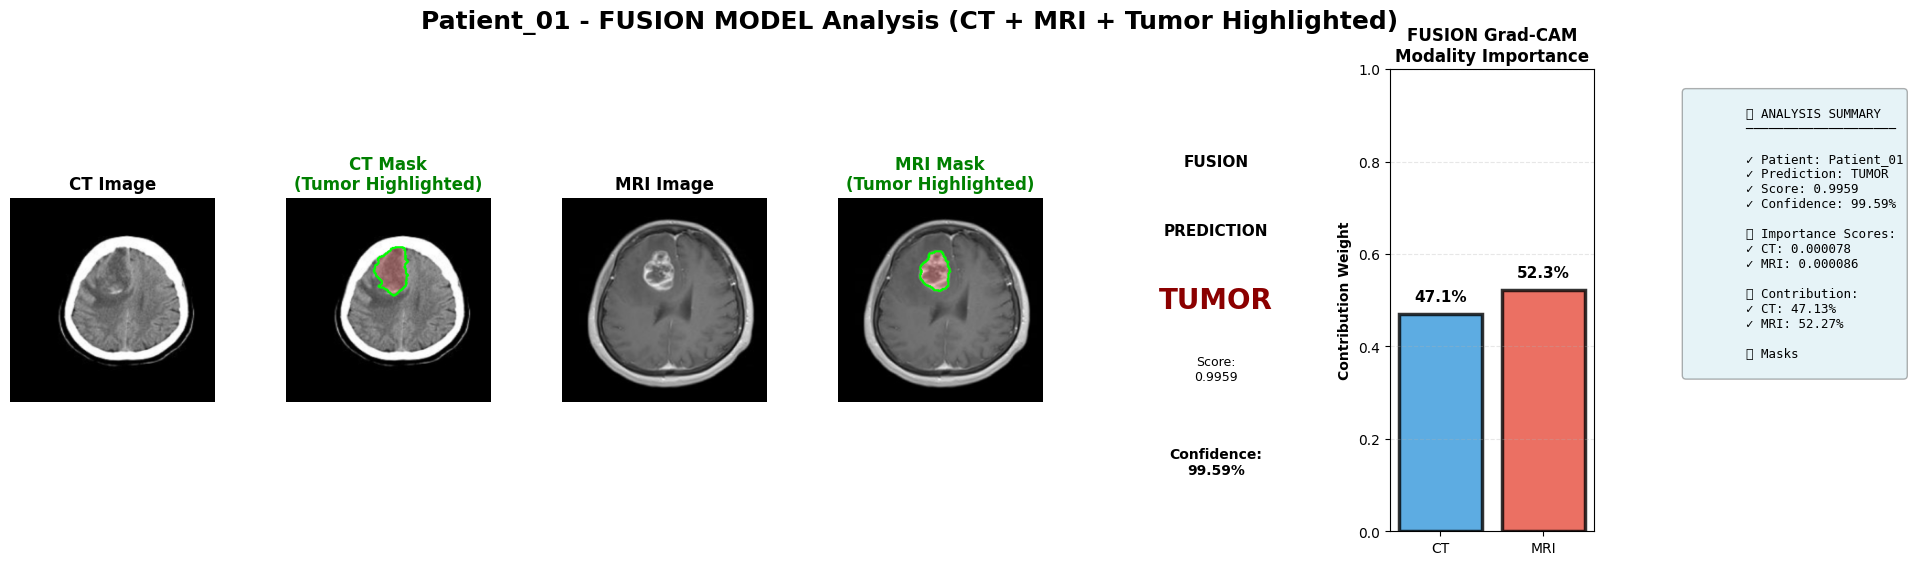

      CT Mask: ✅ Found & Highlighted
      MRI Mask: ✅ Found & Highlighted

   📊 RESULTS:
      Prediction: TUMOR (0.9959)
      Confidence: 99.59%
      CT Importance: 0.000078
      MRI Importance: 0.000086
      CT Weight: 47.13% | MRI Weight: 52.27%

────────────────────────────────────────────────────────────────────────────────
PATIENT 2 / 5
ID: Patient_02
────────────────────────────────────────────────────────────────────────────────
   Processing Patient_02...
      💾 Saved: fusion_patient_gradcam_analysis/Patient_02_Fusion_GradCAM.png


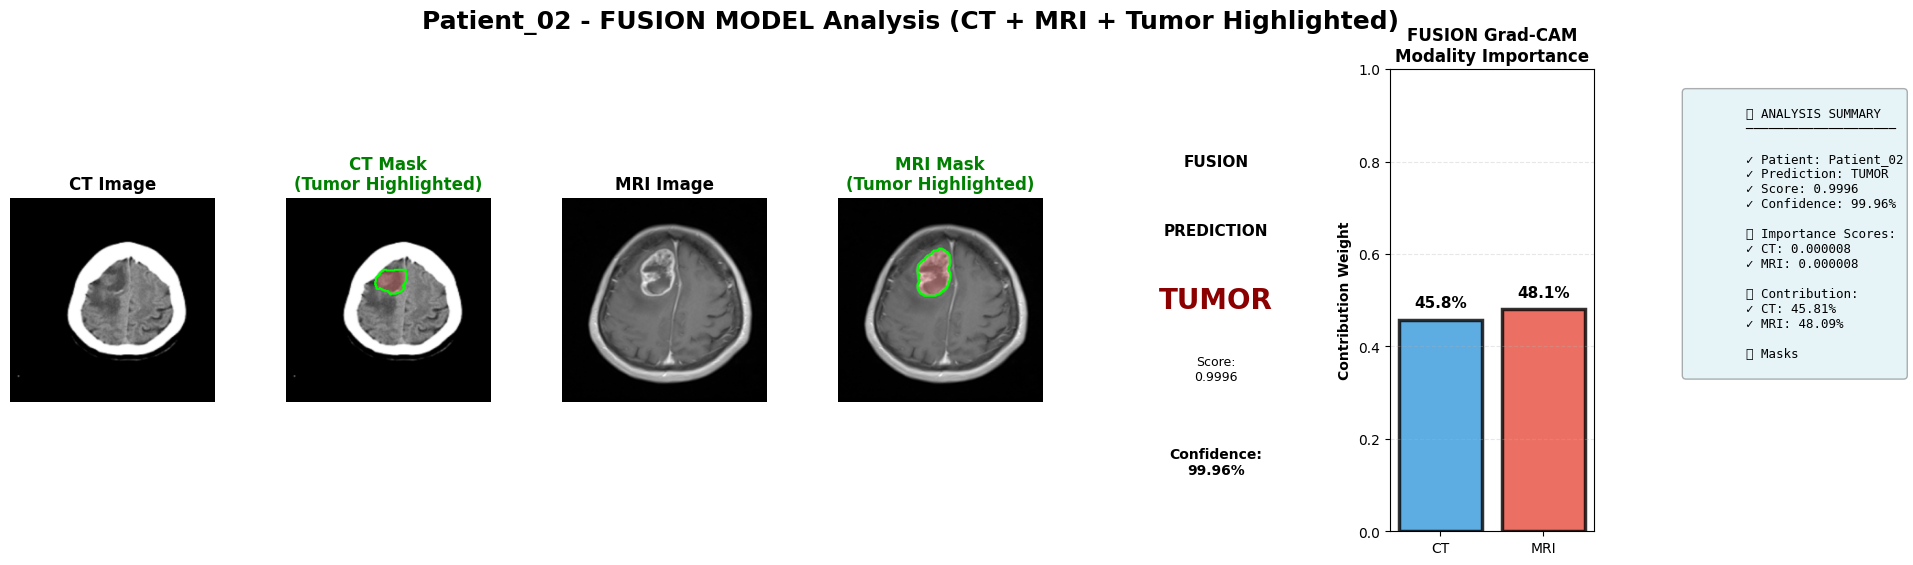

      CT Mask: ✅ Found & Highlighted
      MRI Mask: ✅ Found & Highlighted

   📊 RESULTS:
      Prediction: TUMOR (0.9996)
      Confidence: 99.96%
      CT Importance: 0.000008
      MRI Importance: 0.000008
      CT Weight: 45.81% | MRI Weight: 48.09%

────────────────────────────────────────────────────────────────────────────────
PATIENT 3 / 5
ID: Patient_03
────────────────────────────────────────────────────────────────────────────────
   Processing Patient_03...
      💾 Saved: fusion_patient_gradcam_analysis/Patient_03_Fusion_GradCAM.png


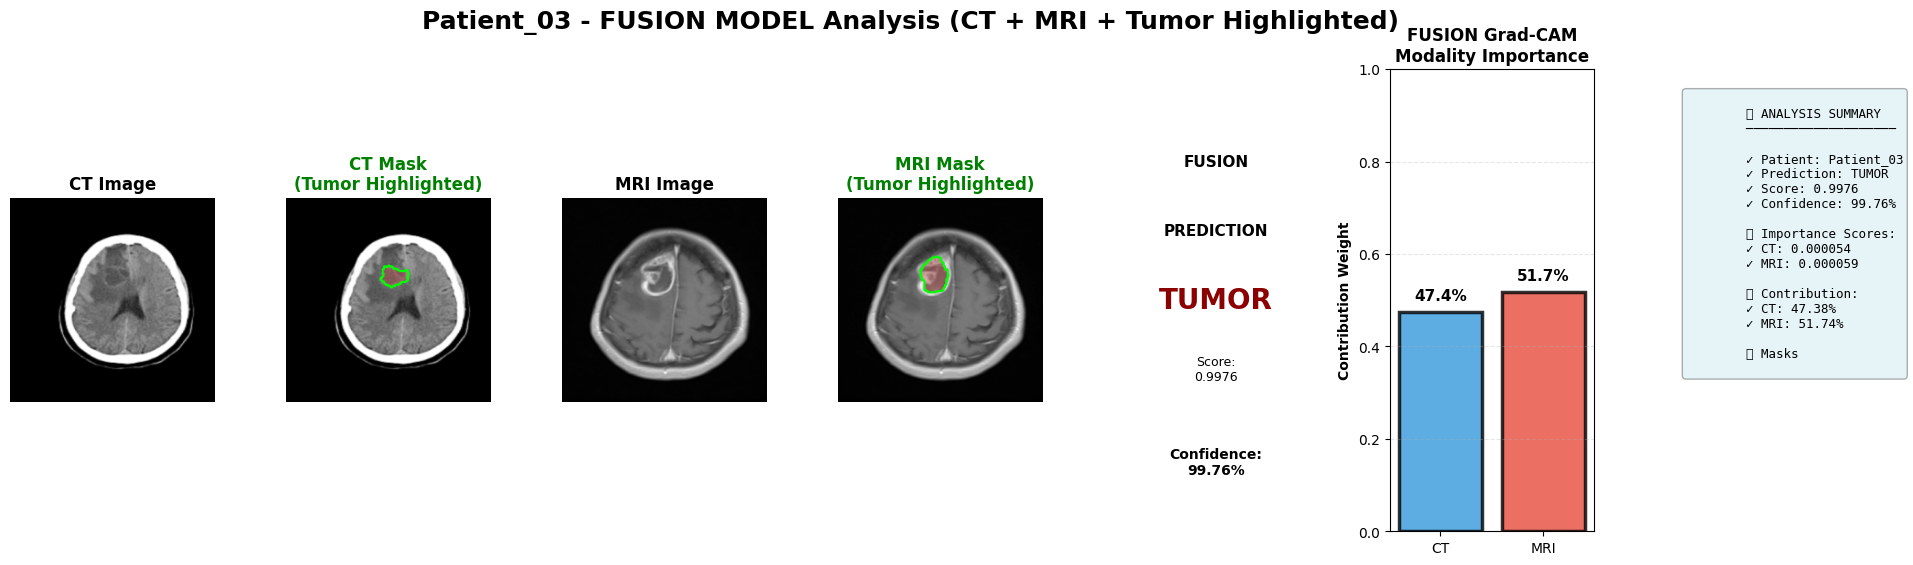

      CT Mask: ✅ Found & Highlighted
      MRI Mask: ✅ Found & Highlighted

   📊 RESULTS:
      Prediction: TUMOR (0.9976)
      Confidence: 99.76%
      CT Importance: 0.000054
      MRI Importance: 0.000059
      CT Weight: 47.38% | MRI Weight: 51.74%

────────────────────────────────────────────────────────────────────────────────
PATIENT 4 / 5
ID: Patient_04
────────────────────────────────────────────────────────────────────────────────
   Processing Patient_04...
      💾 Saved: fusion_patient_gradcam_analysis/Patient_04_Fusion_GradCAM.png


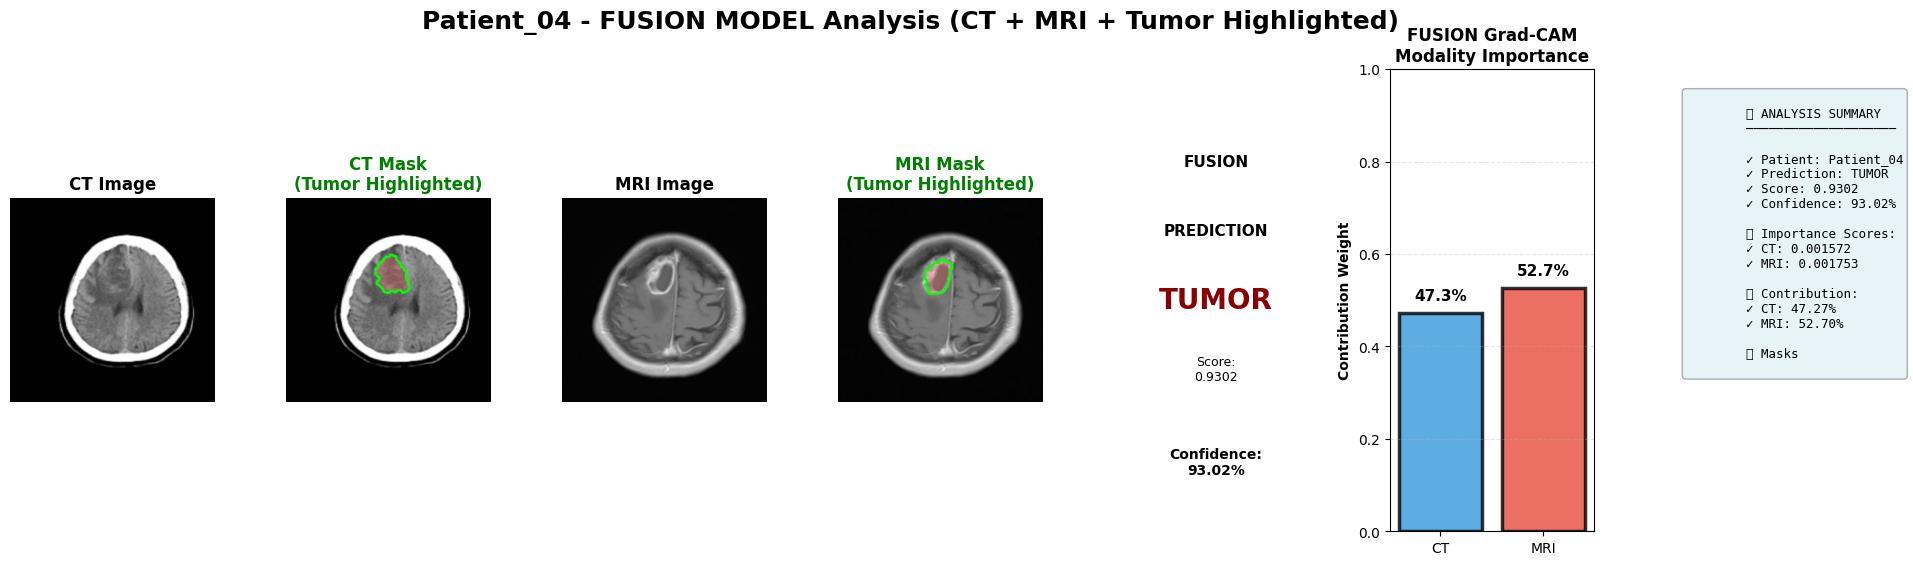

      CT Mask: ✅ Found & Highlighted
      MRI Mask: ✅ Found & Highlighted

   📊 RESULTS:
      Prediction: TUMOR (0.9302)
      Confidence: 93.02%
      CT Importance: 0.001572
      MRI Importance: 0.001753
      CT Weight: 47.27% | MRI Weight: 52.70%

────────────────────────────────────────────────────────────────────────────────
PATIENT 5 / 5
ID: Patient_05
────────────────────────────────────────────────────────────────────────────────
   Processing Patient_05...
      💾 Saved: fusion_patient_gradcam_analysis/Patient_05_Fusion_GradCAM.png


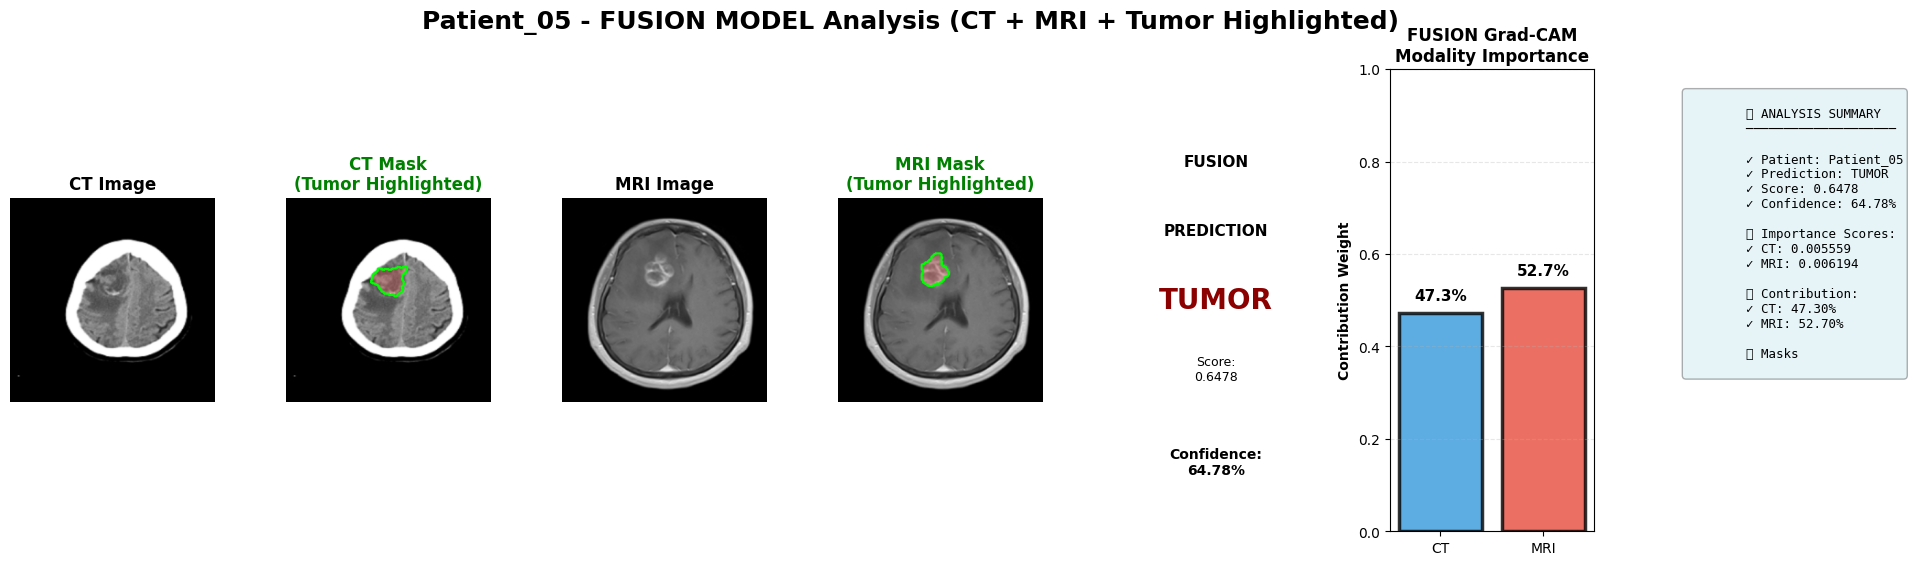

      CT Mask: ✅ Found & Highlighted
      MRI Mask: ✅ Found & Highlighted

   📊 RESULTS:
      Prediction: TUMOR (0.6478)
      Confidence: 64.78%
      CT Importance: 0.005559
      MRI Importance: 0.006194
      CT Weight: 47.30% | MRI Weight: 52.70%

✅ Successfully analyzed 5 patients


In [69]:
print("\n" + "="*80)
print("ANALYZING PATIENT-WISE IMAGES WITH FUSION MODEL GRAD-CAM")
print("="*80)

patient_results = []

for patient in patient_data:
    print(f"\n{'─'*80}")
    print(f"PATIENT {patient['patient_idx']} / {len(patient_data)}")
    print(f"ID: {patient['patient_id']}")
    print(f"{'─'*80}")
    
    result = visualize_patient_gradcam(
        patient,
        ct_extractor, mri_extractor, fusion_model,
        save_path=f"fusion_patient_gradcam_analysis/{patient['patient_id']}_Fusion_GradCAM.png"
    )
    
    if result is not None:
        patient_results.append(result)
        
        print(f"\n   📊 RESULTS:")
        print(f"      Prediction: {result['prediction_class']} ({result['prediction']:.4f})")
        print(f"      Confidence: {result['confidence']:.2%}")
        print(f"      CT Importance: {result['ct_importance']:.6f}")
        print(f"      MRI Importance: {result['mri_importance']:.6f}")
        print(f"      CT Weight: {result['ct_weight']:.2%} | MRI Weight: {result['mri_weight']:.2%}")

print(f"\n{'='*80}")
print(f"✅ Successfully analyzed {len(patient_results)} patients")
print(f"{'='*80}")

In [70]:
if len(patient_results) > 0:
    summary_df = pd.DataFrame([
        {
            'Patient ID': r['patient_id'],
            'Prediction': r['prediction_class'],
            'Score': f"{r['prediction']:.4f}",
            'Confidence': f"{r['confidence']:.2%}",
            'CT Importance': f"{r['ct_importance']:.6f}",
            'MRI Importance': f"{r['mri_importance']:.6f}",
            'CT Weight': f"{r['ct_weight']:.2%}",
            'MRI Weight': f"{r['mri_weight']:.2%}"
        }
        for r in patient_results
    ])
    
    print("\n" + "="*120)
    print("SUMMARY TABLE - PATIENT-WISE FUSION GRAD-CAM ANALYSIS")
    print("="*120)
    print(summary_df.to_string(index=False))
    print("="*120)
    
    summary_df.to_csv("fusion_patient_gradcam_analysis/patient_summary.csv", index=False)
    print("\n✅ Summary saved to: fusion_patient_gradcam_analysis/patient_summary.csv")


SUMMARY TABLE - PATIENT-WISE FUSION GRAD-CAM ANALYSIS
Patient ID Prediction  Score Confidence CT Importance MRI Importance CT Weight MRI Weight
Patient_01      TUMOR 0.9959     99.59%      0.000078       0.000086    47.13%     52.27%
Patient_02      TUMOR 0.9996     99.96%      0.000008       0.000008    45.81%     48.09%
Patient_03      TUMOR 0.9976     99.76%      0.000054       0.000059    47.38%     51.74%
Patient_04      TUMOR 0.9302     93.02%      0.001572       0.001753    47.27%     52.70%
Patient_05      TUMOR 0.6478     64.78%      0.005559       0.006194    47.30%     52.70%

✅ Summary saved to: fusion_patient_gradcam_analysis/patient_summary.csv


In [71]:
if len(patient_results) > 0:
    predictions = [r['prediction'] for r in patient_results]
    ct_weights = [r['ct_weight'] for r in patient_results]
    mri_weights = [r['mri_weight'] for r in patient_results]
    
    print("\n" + "="*80)
    print("STATISTICAL ANALYSIS")
    print("="*80)
    
    print("\n📊 FUSION PREDICTIONS:")
    print(f"   Mean Score: {np.mean(predictions):.4f}")
    print(f"   Std Dev: {np.std(predictions):.4f}")
    print(f"   Min: {np.min(predictions):.4f} | Max: {np.max(predictions):.4f}")
    
    print("\n📊 MODALITY BALANCE:")
    print(f"   Mean CT Weight: {np.mean(ct_weights):.2%}")
    print(f"   Mean MRI Weight: {np.mean(mri_weights):.2%}")
    
    print("\n📊 PREDICTIONS:")
    tumor_count = sum(1 for r in patient_results if r['prediction_class'] == 'TUMOR')
    healthy_count = len(patient_results) - tumor_count
    print(f"   Tumors: {tumor_count} / {len(patient_results)}")
    print(f"   Healthy: {healthy_count} / {len(patient_results)}")
    
    print("\n" + "="*80)


STATISTICAL ANALYSIS

📊 FUSION PREDICTIONS:
   Mean Score: 0.9142
   Std Dev: 0.1357
   Min: 0.6478 | Max: 0.9996

📊 MODALITY BALANCE:
   Mean CT Weight: 46.98%
   Mean MRI Weight: 51.50%

📊 PREDICTIONS:
   Tumors: 5 / 5
   Healthy: 0 / 5



✅ Summary visualization saved


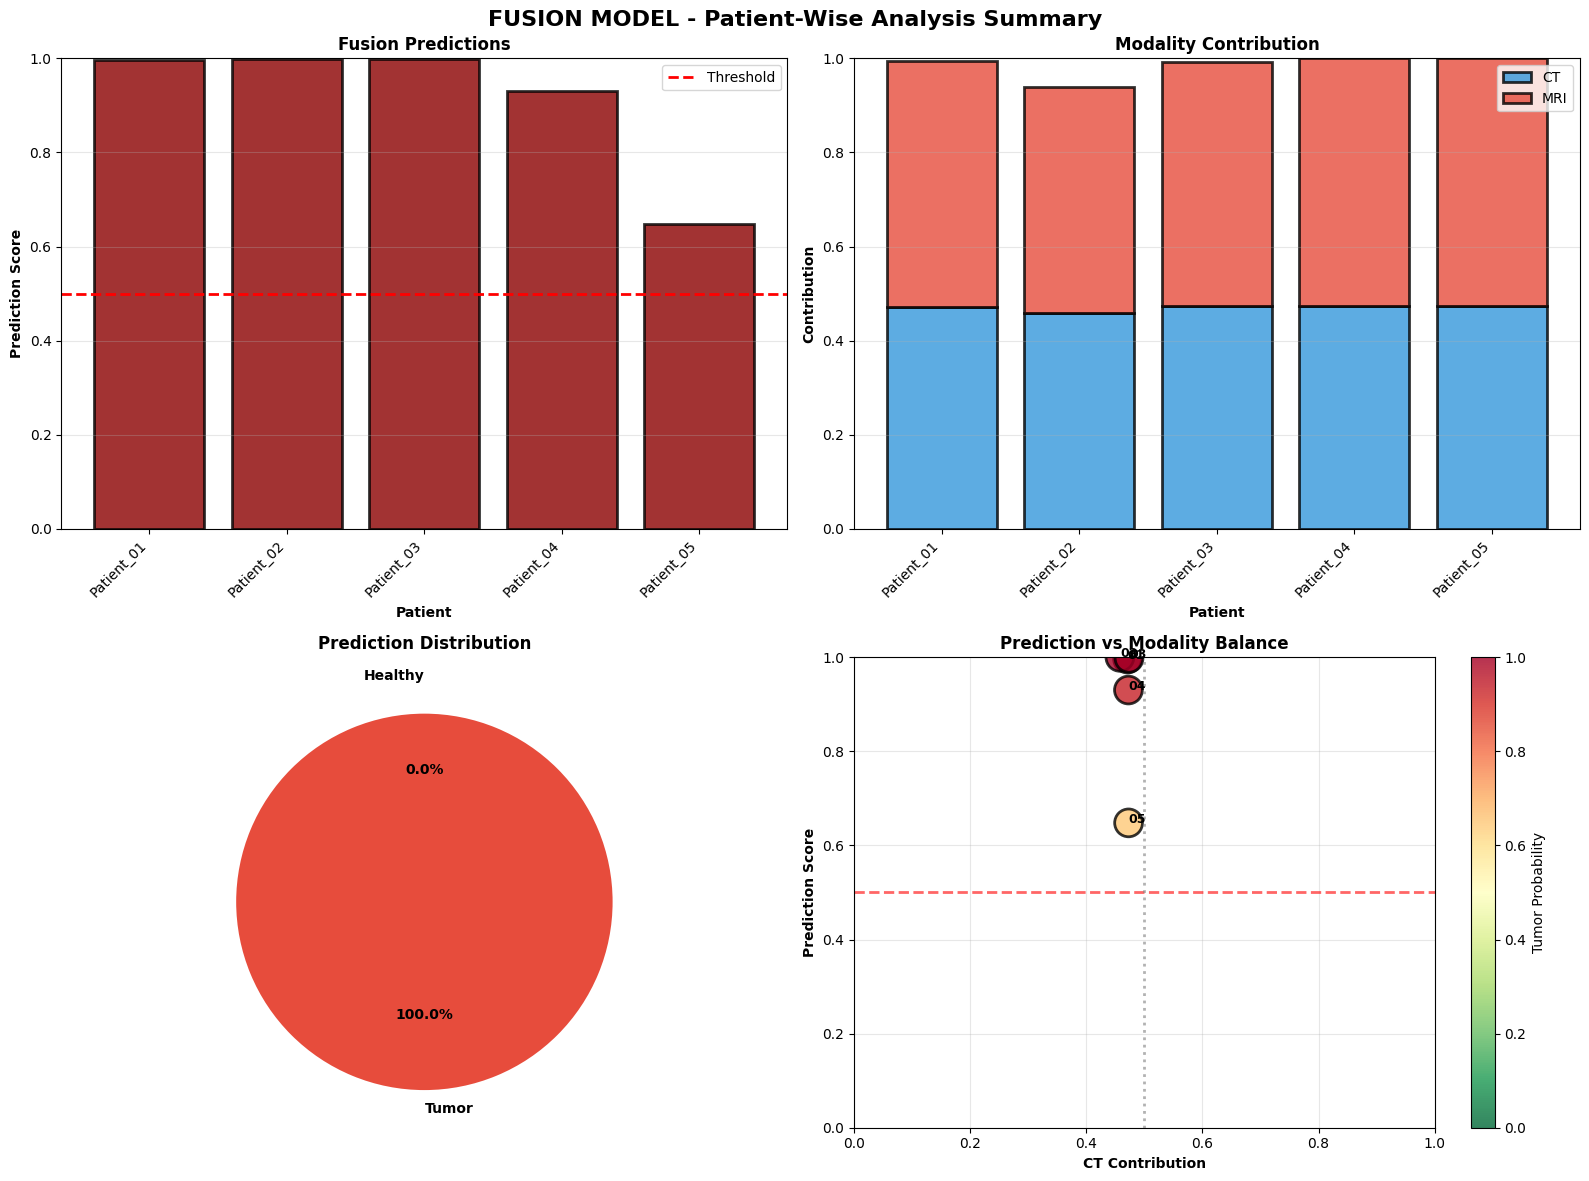

In [72]:
if len(patient_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('FUSION MODEL - Patient-Wise Analysis Summary', fontsize=16, fontweight='bold')
    
    predictions = [r['prediction'] for r in patient_results]
    ct_weights = [r['ct_weight'] for r in patient_results]
    mri_weights = [r['mri_weight'] for r in patient_results]
    patient_names = [r['patient_id'] for r in patient_results]
    
    # Plot 1: Predictions
    ax = axes[0, 0]
    colors = ['darkred' if p > 0.5 else 'darkgreen' for p in predictions]
    bars = ax.bar(range(len(predictions)), predictions, color=colors, edgecolor='black', linewidth=2, alpha=0.8)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=2, label='Threshold')
    ax.set_xlabel('Patient', fontweight='bold')
    ax.set_ylabel('Prediction Score', fontweight='bold')
    ax.set_title('Fusion Predictions', fontweight='bold')
    ax.set_xticks(range(len(predictions)))
    ax.set_xticklabels(patient_names, rotation=45, ha='right')
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 2: Modality Contribution
    ax = axes[0, 1]
    ax.bar(range(len(predictions)), ct_weights, label='CT', color='#3498db', edgecolor='black', linewidth=2, alpha=0.8)
    ax.bar(range(len(predictions)), mri_weights, bottom=ct_weights, label='MRI', color='#e74c3c', edgecolor='black', linewidth=2, alpha=0.8)
    ax.set_xlabel('Patient', fontweight='bold')
    ax.set_ylabel('Contribution', fontweight='bold')
    ax.set_title('Modality Contribution', fontweight='bold')
    ax.set_xticks(range(len(predictions)))
    ax.set_xticklabels(patient_names, rotation=45, ha='right')
    ax.set_ylim([0, 1])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Plot 3: Prediction Distribution
    ax = axes[1, 0]
    tumor_count = sum(1 for r in patient_results if r['prediction_class'] == 'TUMOR')
    healthy_count = len(patient_results) - tumor_count
    colors_pie = ['#e74c3c', '#2ecc71']
    explode = (0.05, 0.05)
    ax.pie([tumor_count, healthy_count], labels=['Tumor', 'Healthy'], autopct='%1.1f%%',
           colors=colors_pie, explode=explode, startangle=90, textprops={'fontweight': 'bold'})
    ax.set_title('Prediction Distribution', fontweight='bold')
    
    # Plot 4: Scatter
    ax = axes[1, 1]
    scatter = ax.scatter(ct_weights, predictions, s=400, c=predictions, cmap='RdYlGn_r',
                        edgecolor='black', linewidth=2, alpha=0.8, vmin=0, vmax=1)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=2, alpha=0.6)
    ax.axvline(0.5, color='gray', linestyle=':', linewidth=2, alpha=0.6)
    ax.set_xlabel('CT Contribution', fontweight='bold')
    ax.set_ylabel('Prediction Score', fontweight='bold')
    ax.set_title('Prediction vs Modality Balance', fontweight='bold')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True, alpha=0.3)
    
    for i, name in enumerate(patient_names):
        ax.annotate(name.split('_')[-1], (ct_weights[i], predictions[i]), fontsize=9, fontweight='bold')
    
    plt.colorbar(scatter, ax=ax, label='Tumor Probability')
    plt.tight_layout()
    plt.savefig("fusion_patient_gradcam_analysis/Summary_Visualization.png", dpi=150, bbox_inches='tight')
    print("✅ Summary visualization saved")
    plt.show()

In [73]:
if len(patient_results) > 0:
    print("\n" + "="*80)
    print("✅ PATIENT-WISE ANALYSIS COMPLETE!")
    print("="*80)
    
    print("\n📁 Output Files Generated:")
    for r in patient_results:
        print(f"   ├── {r['patient_id']}_Fusion_GradCAM.png")
    print("   ├── Summary_Visualization.png")
    print("   └── patient_summary.csv")
    
    print("\n📊 Analysis Summary:")
    print(f"   ✓ Patients analyzed: {len(patient_results)}")
    print(f"   ✓ Tumors detected: {sum(1 for r in patient_results if r['prediction_class'] == 'TUMOR')}")
    print(f"   ✓ Healthy cases: {sum(1 for r in patient_results if r['prediction_class'] == 'HEALTHY')}")
    
    print("\n🎯 Key Features:")
    print(f"   ✓ Tumor regions highlighted with colored overlays")
    print(f"   ✓ Green contours show tumor boundaries")
    print(f"   ✓ Grad-CAM shows CT vs MRI importance")
    print(f"   ✓ All visualizations saved with high resolution")
    
    print("\n" + "="*80)
    print("✅ Ready for clinical review! 🎉")
    print("="*80)


✅ PATIENT-WISE ANALYSIS COMPLETE!

📁 Output Files Generated:
   ├── Patient_01_Fusion_GradCAM.png
   ├── Patient_02_Fusion_GradCAM.png
   ├── Patient_03_Fusion_GradCAM.png
   ├── Patient_04_Fusion_GradCAM.png
   ├── Patient_05_Fusion_GradCAM.png
   ├── Summary_Visualization.png
   └── patient_summary.csv

📊 Analysis Summary:
   ✓ Patients analyzed: 5
   ✓ Tumors detected: 5
   ✓ Healthy cases: 0

🎯 Key Features:
   ✓ Tumor regions highlighted with colored overlays
   ✓ Green contours show tumor boundaries
   ✓ Grad-CAM shows CT vs MRI importance
   ✓ All visualizations saved with high resolution

✅ Ready for clinical review! 🎉
